# Week 07 · Image Restoration & Morphological Processing
**Course:** Computer Vision (BCSE2022)
**Instructor:** Bùi Huy Kiên
**Prepared:** 2026-07-15


## 🎯 Mục tiêu học tập
Sau khi hoàn thành bài học này, sinh viên sẽ có thể:
- Nhận biết các mô hình nhiễu cơ bản (Gaussian, uniform, salt & pepper) qua histogram của vùng ảnh phẳng.
- Áp dụng các bộ lọc thống kê thứ tự (median, contraharmonic) để khôi phục ảnh nhiễu; hiểu khi nào mỗi bộ lọc phù hợp.
- Khử nhiễu tuần hoàn (periodic noise) bằng bộ lọc notch trong miền tần số.
- Nắm các phép toán hình thái học cơ bản: co (erosion), giãn (dilation), mở (opening), đóng (closing).
- Vận dụng hình thái học: khử nhiễu ảnh nhị phân, trích xuất biên, gradient hình thái.


**Hướng dẫn:**
- Ảnh mẫu lấy từ bộ ảnh sách Gonzalez & Woods (DIP 3rd ed.) trong thư mục `Gonzalez_images/` ở gốc repo.
- Mỗi cell hiển thị ảnh dùng `matplotlib`.
- Sử dụng các thư viện: `opencv-python`, `numpy`, `matplotlib`.
- Nếu được, khuyến khích xây dựng lại các thuật toán sử dụng C++/Python


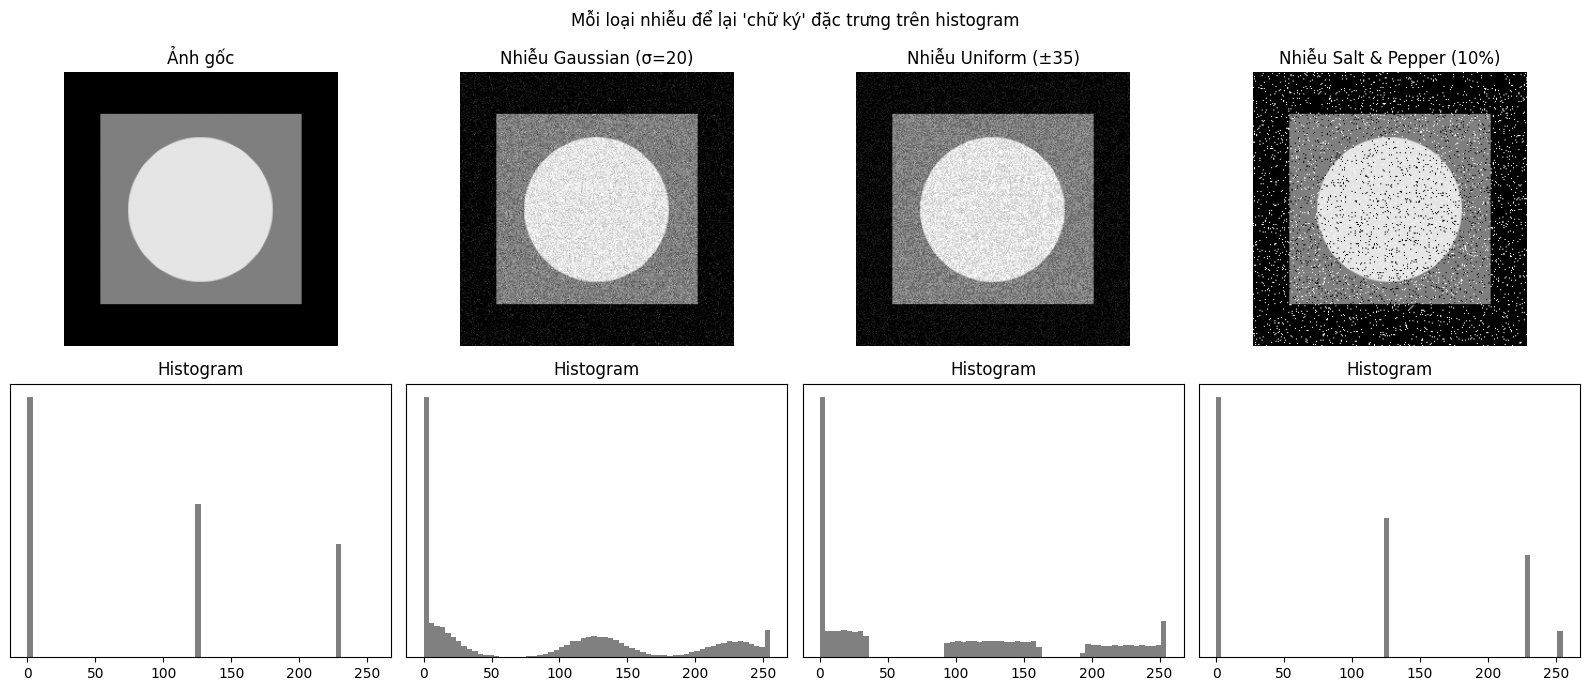

In [1]:
## Ví dụ 1: Các mô hình nhiễu và "chữ ký" trên histogram
# Thêm 3 loại nhiễu vào ảnh test pattern (Gonzalez Fig 5.3-5.4).
# Histogram của vùng ảnh phẳng cho biết loại nhiễu: hình chuông (Gaussian),
# chữ nhật (uniform), hai xung ở 0 và 255 (salt & pepper).

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_CH05_Original_Images/Fig0503 (original_pattern).tif").convert("L")).astype(np.float64)
rng = np.random.default_rng(0)

noisy_gauss = np.clip(img + rng.normal(0, 20, img.shape), 0, 255)
noisy_unif  = np.clip(img + rng.uniform(-35, 35, img.shape), 0, 255)
noisy_sp = img.copy()
r = rng.random(img.shape)
noisy_sp[r < 0.05] = 0
noisy_sp[r > 0.95] = 255

cases = [("Ảnh gốc", img), ("Nhiễu Gaussian (σ=20)", noisy_gauss),
         ("Nhiễu Uniform (±35)", noisy_unif), ("Nhiễu Salt & Pepper (10%)", noisy_sp)]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, (t, im) in enumerate(cases):
    axes[0, j].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, j].set_title(t); axes[0, j].axis("off")
    axes[1, j].hist(im.ravel(), bins=64, range=(0, 255), color="gray")
    axes[1, j].set_title("Histogram"); axes[1, j].set_yticks([])
plt.suptitle("Mỗi loại nhiễu để lại 'chữ ký' đặc trưng trên histogram")
plt.tight_layout()
plt.show()


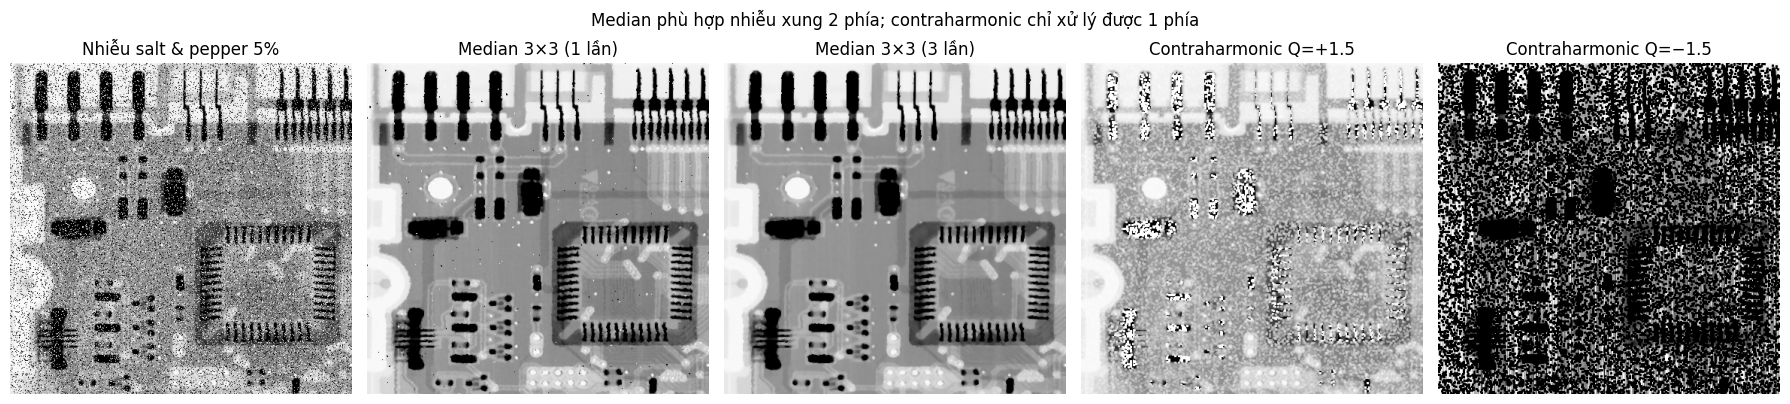

In [2]:
## Ví dụ 2: Khôi phục nhiễu salt & pepper — Median vs Contraharmonic
# Ảnh mạch điện nhiễu salt & pepper 5% (Gonzalez Fig 5.10).
# - Median: khử tốt cả salt lẫn pepper, lặp lại nhiều lần càng sạch.
# - Contraharmonic bậc Q: Q > 0 khử pepper, Q < 0 khử salt — chọn SAI dấu sẽ phản tác dụng!

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

noisy = np.asarray(Image.open("../../Gonzalez_images/DIP3E_CH05_Original_Images/Fig0510(a)(ckt-board-saltpep-prob.pt05).tif").convert("L"))

def contraharmonic(img, ksize, Q):
    """Bộ lọc contraharmonic mean bậc Q, cửa sổ ksize x ksize."""
    f = img.astype(np.float64) + 1e-8
    num = cv2.blur(f ** (Q + 1), (ksize, ksize))
    den = cv2.blur(f ** Q, (ksize, ksize))
    return np.clip(num / den, 0, 255)

median1 = cv2.medianBlur(noisy, 3)
median3 = cv2.medianBlur(cv2.medianBlur(median1, 3), 3)   # lọc 3 lần
chm_pos = contraharmonic(noisy, 3, Q=+1.5)   # khử pepper nhưng làm salt tệ hơn
chm_neg = contraharmonic(noisy, 3, Q=-1.5)   # khử salt nhưng làm pepper tệ hơn

titles = ["Nhiễu salt & pepper 5%", "Median 3×3 (1 lần)", "Median 3×3 (3 lần)",
          "Contraharmonic Q=+1.5", "Contraharmonic Q=−1.5"]
images = [noisy, median1, median3, chm_pos, chm_neg]

fig, axes = plt.subplots(1, 5, figsize=(18, 4.2))
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(t); ax.axis("off")
plt.suptitle("Median phù hợp nhiễu xung 2 phía; contraharmonic chỉ xử lý được 1 phía")
plt.tight_layout()
plt.show()


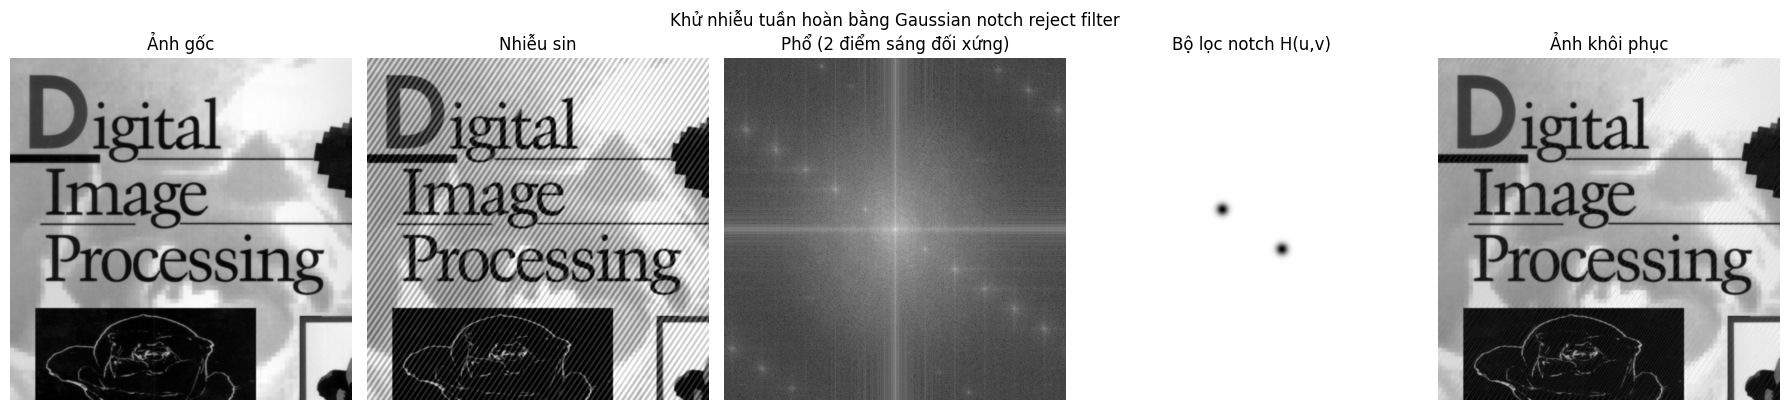

In [3]:
## Ví dụ 3: Nhiễu tuần hoàn và bộ lọc Notch trong miền tần số
# Nhiễu sin xuất hiện thành các CẶP ĐIỂM SÁNG đối xứng trên phổ.
# Bộ lọc notch reject "đục" đúng các điểm đó -> loại nhiễu mà gần như không hại ảnh.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_CH05_Original_Images/Fig0526(a)(original_DIP).tif").convert("L")).astype(np.float64)
M, N = img.shape

# Thêm nhiễu sin 2-D
x = np.arange(N); y = np.arange(M)
X, Y = np.meshgrid(x, y)
u0, v0 = 40, 60          # tần số nhiễu (chu kỳ/ảnh)
noise = 40 * np.sin(2 * np.pi * (u0 * Y / M + v0 * X / N))
noisy = np.clip(img + noise, 0, 255)

F = np.fft.fftshift(np.fft.fft2(noisy))
spec = np.log1p(np.abs(F))

# Notch reject kiểu Gaussian tại (±u0, ±v0)
u = np.arange(M) - M // 2; v = np.arange(N) - N // 2
Vg, Ug = np.meshgrid(v, u)
def gaussian_notch(du, dv, sigma=8):
    D1 = np.sqrt((Ug - du) ** 2 + (Vg - dv) ** 2)
    D2 = np.sqrt((Ug + du) ** 2 + (Vg + dv) ** 2)
    return (1 - np.exp(-D1**2 / (2 * sigma**2))) * (1 - np.exp(-D2**2 / (2 * sigma**2)))

H = gaussian_notch(u0, v0)
restored = np.clip(np.real(np.fft.ifft2(np.fft.ifftshift(F * H))), 0, 255)

fig, axes = plt.subplots(1, 5, figsize=(18, 4.2))
for ax, (t, im) in zip(axes, [("Ảnh gốc", img), ("Nhiễu sin", noisy),
                              ("Phổ (2 điểm sáng đối xứng)", spec),
                              ("Bộ lọc notch H(u,v)", H),
                              ("Ảnh khôi phục", restored)]):
    ax.imshow(im, cmap="gray")
    ax.set_title(t); ax.axis("off")
plt.suptitle("Khử nhiễu tuần hoàn bằng Gaussian notch reject filter")
plt.tight_layout()
plt.show()


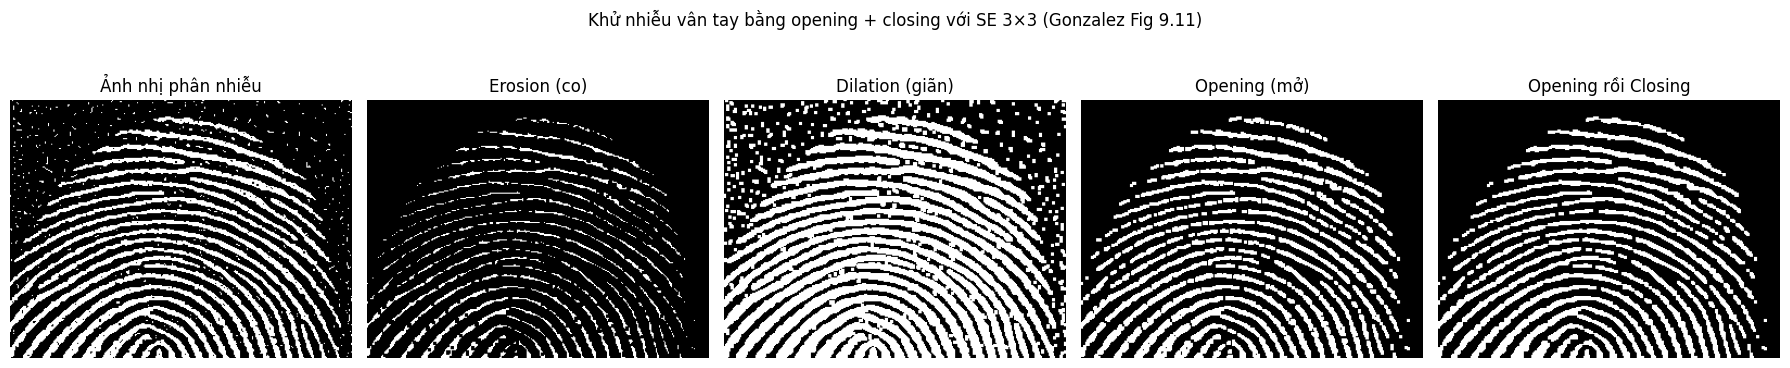

In [4]:
## Ví dụ 4: Hình thái học cơ bản — khử nhiễu ảnh vân tay nhị phân
# Ví dụ kinh điển Gonzalez Fig 9.11: opening loại chấm trắng nhiễu,
# closing lấp lỗ đen — kết hợp opening rồi closing cho ảnh sạch.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH09/Fig0911(a)(noisy_fingerprint).tif").convert("L"))
binary = (img > 128).astype(np.uint8) * 255
se = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

eroded  = cv2.erode(binary, se)
dilated = cv2.dilate(binary, se)
opened  = cv2.morphologyEx(binary, cv2.MORPH_OPEN, se)
closed_after_open = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, se)

titles = ["Ảnh nhị phân nhiễu", "Erosion (co)", "Dilation (giãn)",
          "Opening (mở)", "Opening rồi Closing"]
images = [binary, eroded, dilated, opened, closed_after_open]

fig, axes = plt.subplots(1, 5, figsize=(18, 4.2))
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(t); ax.axis("off")
plt.suptitle("Khử nhiễu vân tay bằng opening + closing với SE 3×3 (Gonzalez Fig 9.11)")
plt.tight_layout()
plt.show()


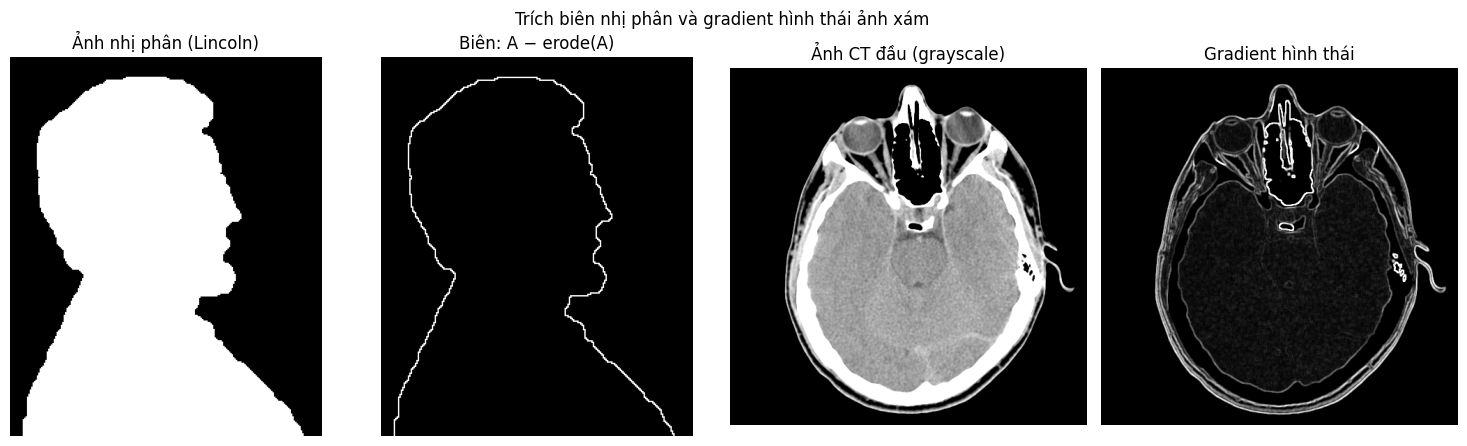

In [5]:
## Ví dụ 5: Ứng dụng hình thái học — trích biên và gradient hình thái
# - Biên trong: β(A) = A − erode(A)  (trên ảnh nhị phân, Gonzalez Fig 9.14).
# - Gradient hình thái (ảnh xám): dilate(f) − erode(f) — làm nổi biên mọi hướng.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# --- Biên nhị phân: chân dung Lincoln trên đồng xu ---
lincoln = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH09/Fig0914(a)(licoln from penny).tif").convert("L"))
lincoln_bin = (lincoln > 128).astype(np.uint8) * 255
se3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
boundary = cv2.subtract(lincoln_bin, cv2.erode(lincoln_bin, se3))

# --- Gradient hình thái trên ảnh xám: CT đầu ---
head = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH09/Fig0939(a)(headCT-Vandy).tif").convert("L"))
grad = cv2.morphologyEx(head, cv2.MORPH_GRADIENT, se3)

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
axes[0].imshow(lincoln_bin, cmap="gray"); axes[0].set_title("Ảnh nhị phân (Lincoln)")
axes[1].imshow(boundary, cmap="gray");    axes[1].set_title("Biên: A − erode(A)")
axes[2].imshow(head, cmap="gray");        axes[2].set_title("Ảnh CT đầu (grayscale)")
axes[3].imshow(grad, cmap="gray");        axes[3].set_title("Gradient hình thái")
for ax in axes: ax.axis("off")
plt.suptitle("Trích biên nhị phân và gradient hình thái ảnh xám")
plt.tight_layout()
plt.show()


## 📝 Exercises (en)
1. Add Gaussian noise (σ = 20) to the circuit-board image `Fig0507(a)(ckt-board-orig).tif` (CH05) and compare arithmetic mean, geometric mean, and median filters (5×5). Which preserves detail best?
2. Restore `Fig0508(a)(circuit-board-pepper-prob-pt1).tif` and `Fig0508(b)(circuit-board-salt-prob-pt1).tif` (CH05) with contraharmonic filters. Choose Q for each case and explain.
3. Implement the **adaptive median filter** (Gonzalez §5.3.3) and test it on `Fig0514(a)(ckt_saltpep_prob_pt25).tif` (25% noise). Compare with a plain 7×7 median.
4. Use morphology to fill the holes in `Fig0916(a)(region-filling-reflections).tif` (CH09) — implement hole filling with iterative dilation constrained by the complement.
5. Extract only the bones from `Fig0918(a)(Chickenfilet with bones).tif` (CH09) using top-hat / bottom-hat transforms.

## 📝 Bài tập (vi)
1. Thêm nhiễu Gaussian (σ = 20) vào ảnh mạch điện `Fig0507(a)(ckt-board-orig).tif` (CH05) và so sánh lọc trung bình cộng, trung bình nhân và median (5×5). Bộ lọc nào giữ chi tiết tốt nhất?
2. Khôi phục `Fig0508(a)(circuit-board-pepper-prob-pt1).tif` và `Fig0508(b)(circuit-board-salt-prob-pt1).tif` (CH05) bằng bộ lọc contraharmonic. Chọn Q cho từng trường hợp và giải thích.
3. Cài đặt **bộ lọc median thích nghi** (Gonzalez §5.3.3) và thử trên `Fig0514(a)(ckt_saltpep_prob_pt25).tif` (nhiễu 25%). So sánh với median 7×7 thường.
4. Dùng hình thái học lấp lỗ trong `Fig0916(a)(region-filling-reflections).tif` (CH09) — cài đặt hole filling bằng dilation lặp có ràng buộc phần bù.
5. Tách riêng phần xương trong `Fig0918(a)(Chickenfilet with bones).tif` (CH09) bằng biến đổi top-hat / bottom-hat.